# The cost of ammonia production

Analysis of the cost of ammonia based on different technology pathways.

The source of nitrogen is likely to be air separation through the course of the energy transition.

However, the hydrogen production is likely to involve carbon capture and utilization (CCU) along side tradition methane reforming production [Blue pathway]
Or electrolysis [Green pathway].

To this end, the framework is used to analyze the cost of hydrogen production as a result of the technologies avaible at our disposal, as also the trade-offs interms of emissions when considering them.


Specific features of the study are as follows:

- H2 Use for Ammonia production:  400,000 to 500,000 kg H2/day; we may add other production volumes later

- H2 carbon intensity:  100% renewable electrolysis (0 kg CO2 / kg H2); 95% CCS + ATR/SMR (0.4 kg CO2/kg H2 – this qualifies for the $3/kg H2 PTC); There might be a 90% CCS case in some of the projects, but not sure yet on that. 

- H2 Cost:  The partners have provided no data, so we have to make some assumptions.  Let’s start with $1/kg H2 for now.  Or, maybe you can back out what this number should be based on the Ammonia market. 

- Ammonia price:  I’ll let you define this.  I think the goal would be for clean hydrogen based ammonia to be competitive with dirty hydrogen ammonia. 

__author__ = "Rahul Kakodkar", "Swaminathan Sundar", "Efstratios Pistikopoulos"
__copyright__ = "Copyright 2023, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Swaminathan Sundar", "Efstratios N. Pistikopoulos"]
__license__ = "Open"
__version__ = "1.0.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"

In [1]:
import pandas 
from numpy import poly1d, polyfit, arange
from src.energiapy.components.temporal_scale import Temporal_scale
from src.energiapy.components.resource import Resource
from src.energiapy.components.process import Process
from src.energiapy.components.material import Material
from src.energiapy.components.location import Location
from src.energiapy.components.network import Network
from src.energiapy.components.scenario import Scenario
from src.energiapy.components.transport import Transport
from src.energiapy.components.result import Result 
from src.energiapy.model.formulate import formulate, Constraints, Objective
from src.energiapy.plot import plot
from src.energiapy.model.solve import solve
import matplotlib.pyplot as plt
from matplotlib import rc
from itertools import product
from pyomo.environ import Constraint, Set
from src.energiapy.utils.data_utils import get_data, make_henry_price_df
from src.energiapy.utils.cluster_utils import reduce_scenario, Clustermethod

In [2]:
weather20_df = pandas.read_csv('data/ho_solar20.csv', index_col=0)
weather20_df.index = [i.split('+')[0] for i in weather20_df.index]
weather = weather20_df[~weather20_df.index.str.contains('02-29')] #remove leap years
weather

,wind_speed,dni
2020-01-01 00:00:00,9.5,0.0
2020-01-01 01:00:00,7.5,0.0
2020-01-01 02:00:00,6.0,0.0
2020-01-01 03:00:00,6.0,0.0
2020-01-01 04:00:00,6.0,0.0
...,...,...
2020-12-31 19:00:00,54.5,0.5
2020-12-31 20:00:00,55.5,0.0
2020-12-31 21:00:00,50.0,0.0
2020-12-31 22:00:00,46.0,181.5


In [3]:
#Actual temporal scale (daily)
ng_price20 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2020, stretch=True)
ng_price_df = ng_price20
ng_price_df['index'] = [i for i in weather.index]
ng_price_df = ng_price_df.drop(columns= 'scales')
ng_price = ng_price_df.set_index('index')
ng_price

,CH4
index,
2020-01-01 00:00:00,0.093304
2020-01-01 01:00:00,0.093304
2020-01-01 02:00:00,0.093304
2020-01-01 03:00:00,0.093304
2020-01-01 04:00:00,0.093304
...,...
2020-12-31 19:00:00,0.105357
2020-12-31 20:00:00,0.105357
2020-12-31 21:00:00,0.105357


**Constants**

In [4]:
bigM = 10**10 # very large number
smallM = 0.1
water_price = 31.70  # $/5000gallons
power_price = 8  # cents/kWh
ur_price = 42.70  # 250 Pfund U308 (Uranium)
A_f = 0.05  # annualization factor
# CO2_res = 0.2
pv_start = 0
ake_start = 0
smrh_start = 0
smr_start = 0
asmr_start = 0
demand = 450000*(0.822/0.178)/24

In [5]:
cost_dict = get_data(file_name='data/cost_dict')
for i in cost_dict['HO']['moderate'].keys():
    print(i + ':', cost_dict['HO']['moderate'][i]['0'])

LiI_c: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
LiI_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
CAES_c: {'CAPEX': 1669000.0, 'Fixed O&M': 16700.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.pnm.com/documents/396023/1506047/2017+-+HDR+10-30-17+PNM+Energy+Storage+Report.pdf/a2b7ca65-e1ba-92c8-308a-9a8391a87331'}
CAES_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PSH_c: {'CAPEX': 0, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 4435.188, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
PSH_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PV: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'sour

**Resources**

In [6]:
Charge = Resource(name='Charge', store_max=1000, basis='MW', label='Battery energy', block='energystorage')

Air_C = Resource(name='Air_C', store_max=bigM, basis='MW', label='CAES energy', block='energystorage')

H2O_E = Resource(name='H2O_E', store_max=bigM, basis='MW',
                 label='PSH energy', block='energystorage')

Uranium = Resource(name='Uranium', cons_max=(1/4.17*10**(-5))*bigM,
                   price=ur_price/(250/2), basis='kg', label='Uranium', block='energyfeedstock')

Solar = Resource(
    name='Solar', cons_max=bigM, basis='MW', label='Solar Power', block='energyfeedstock')

Wind = Resource(name='Wind', cons_max= bigM, basis='MW', label='Wind Power', block='energyfeedstock')

# H2 = Resource(name='H2', basis='kg', sell = True, demand = True, label='Hydrogen', block='Resource')
H2 = Resource(name='H2', basis='kg', label='Hydrogen', block='Resource')


H2O = Resource(name='H2O', cons_max=10**10,
               price=water_price/(5000*3.7854), basis='kg', label='Water', block='Resource')
            
O2 = Resource(name='O2', sell=True, loss=0.07,
              basis='kg', label='Oxygen', block='Resource')


# CH4 = Resource(name='CH4', cons_max=10**10, price=0.113891, basis='kg', varying= True,\
#     label='Natural gas', block='materialfeedstock')

CH4 = Resource(name='CH4', cons_max=10**10, price=0.05, basis='kg', varying= True,\
    label='Natural gas', block='materialfeedstock')


CO2 = Resource(name='CO2', basis='kg',
               label='Carbon dioxide', block='Resource')

CO2_AQoff = Resource(
    name='CO2_AQoff', store_max=10**10, basis='kg', label='Carbon dioxide - sequestered', block='carbonsequestration')

CO2_EOR = Resource(
    name='CO2_EOR', store_max=10**10, basis='kg', label='Carbon dioxide - EOR', block='carbonsequestration')


CO2_Vent = Resource(
    name='CO2_Vent', sell=True, basis='kg', label='Carbon dioxide - Vented', block='resourcedischarge')

# Power= Resource(name= 'Power', sell= True, store_max=0,   \
#    mile= (10**3)/(0.2167432**1.60934), label= 'Renewable power generated')

Power = Resource(name='Power', basis='MW',
                 label='Renewable power generated', block='Resource')

#TODO

N2 = Resource(name='N2', basis='kg', label='Nitrogen', block='Resource')

NH3 = Resource(name='NH3', basis='kg', sell= True, demand= True, label='Ammonia', block='Resource')

Air = Resource(name='Air', cons_max = bigM, basis = 'MW', label='Air', block='materialfeedstock')



**Process**

In [7]:
LiI_c = Process(name='LiI_c', conversion={Charge: 1, Power: -1}, cost = cost_dict['HO']['moderate']['LiI_c']['0'],\
    prod_max=100, trl='nrel', block='power_storage', label='Lithium-ion battery', citation='Zakeri 2015')

LiI_d = Process(name='LiI_d', conversion={Charge: -1.1765, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=100, trl='discharge', block='power_storage', label='Lithium-ion battery discharge', citation='Zakeri 2015')

CAES_c = Process(name='CAES_c', conversion={Air_C: 1, Power: -1}, cost = cost_dict['HO']['moderate']['CAES_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='pilot', block='power_storage', label='Compressed air energy storage (CAES)', citation='Zakeri 2015')

CAES_d = Process(name='CAES_d', conversion={Air_C: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'},\
    intro_scale=0, prod_max=bigM, trl='discharge', block='power_storage', label='Compressed air energy storage (CAES) discharge', citation='Zakeri 2015')

PSH_c = Process(name='PSH_c', conversion={H2O_E: 1, Power: -1}, cost = cost_dict['HO']['moderate']['PSH_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='nrel', block='power_storage', label='Pumped storage hydropower (PSH)', citation='Zakeri 2015')

PSH_d = Process(name='PSH_d', conversion={H2O_E: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=bigM, trl='discharge', block='power_storage', label='Pumped storage hydropower (PSH) discharge', citation='Zakeri 2015')

WF = Process(name='WF', conversion={Wind: -1, Power: 1, H2O: -1}, cost=cost_dict['HO']['moderate']['WF']['0'],
             prod_max=10**9, gwp=52700, land=10800/1800, trl='nrel', block='power_generation',
             label='Wind mill array', citation='Use windtoolkit conversion', varying= True)

PV = Process(name='PV', intro_scale=pv_start, conversion={Solar: -1, Power: 1, H2O: -20}, cost=cost_dict['HO']['moderate']['PV']['0'],
             prod_max=10**9, gwp=53000, land=13320/1800, trl='nrel', block='power_generation', \
                 label='Solar photovoltaics (PV) array', citation='Use pvlib conversion', varying= True)


NGCC = Process(name='NGCC', conversion={CH4: -1, Power: 1, CO2_Vent: }, cost={'CAPEX': 100911348/(60*60*(19.0235*78/21)), 'Fixed O&M': 0, 'Variable O&M': 0, \
    'units': '$/kg', 'source': ''},
             prod_max=10**9, gwp=0, land=0, block='power_generation',
             label='Natural gas combined cycle power', citation='TBD')

AKE = Process(name='AKE', intro_scale=ake_start, conversion={Power: -1, H2: 19.474, O2: 763.2, H2O: -175.266},
              cost=cost_dict['HO']['moderate']['AKE']['0'], prod_max=bigM, trl='utility', block='material_production',
              label='Alkaline water electrolysis (AWE)', citation='Demirhan et al. 2018 AIChE paper')  # 20.833 MW required to produce 1000t/day.H2

SMRH = Process(name='SMRH', intro_scale=smrh_start, conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 1.03, CO2: 9.332},
               cost=cost_dict['HO']['moderate']['SMRH']['0'], prod_max=bigM, gwp=0, trl='enterprise', block='material_production',
               label='Steam methane reforming + CCUS', citation='Mosca 2020, 90pc capture')

SMR = Process(name='SMR', intro_scale=smr_start, cost= {'CAPEX': 2400, 'Fixed O&M': 800, 'Variable O&M': 0.03, 'units': '$/kg', 'source': 'dummy'}, \
    conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 9.4979}, prod_max=bigM, gwp=0, trl='enterprise',
                      block='material_production', label='Steam methane reforming', citation='Mosca 2020')

ASMR = Process(name='ASMR', conversion={Uranium: -4.17*10**(-5), H2O: -3364.1, Power: 1}, cost=cost_dict['HO']['moderate']['ASMR']['0'],
               intro_scale=asmr_start, gwp=9100, prod_max=bigM, land=1100/1800, trl='pilot', block='power_generation', label='Small modular reactors (SMRs)')

EOR = Process(name='EOR', intro_scale=0, conversion={Power: -0.00255, CO2: -1, CO2_EOR: 1, CO2_Vent: 0.67},
              cost=cost_dict['HO']['moderate']['EOR']['0'], prod_max=bigM, carbon_credit=True,
              trl='enterprise', block='CCUS', label='CO2-Enhanced oil recovery')

AQoff_SMR = Process(name='AQoff_SMR', conversion={Power: -0.00128, CO2_AQoff: 1, CO2: -1}, cost=cost_dict['HO']['moderate']['AQoff_SMR']['0'],
                    prod_max=bigM, carbon_credit=True, trl='repurposed', block='CCUS', label='Offshore aquifer CO2 sequestration (SMR)')

#TODO
ASU = Process(name = 'ASU', conversion = {Air: -1, Power:-1.52*10**(-4), N2: 0.74, O2:0.231}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': 100911348/(60*60*(19.0235*78/21)), 'Fixed O&M': 0, 'Variable O&M': 0, 'units': '$/kg', 'source': 'https://www.sciencedirect.com/science/article/pii/S0360544215008397'}, label = 'air separation, around 2.7 dollars/kg N2')

HB = Process(name = 'HB', conversion = {H2: -0.178, N2:-0.822, Power: -1.476*10**(-3), NH3: 1}, prod_max= bigM, gwp = 0, \
    cost={'CAPEX': 737000000/500000, 'Fixed O&M': 0, 'Variable O&M': 0, 'units': '$/kg', 'source': 'https://ars.els-cdn.com/content/image/1-s2.0-S0306261920314604-mmc1.pdf'}, label = 'Haber Bosch')
    

In [8]:
scales = Temporal_scale([1, 365, 24])

**Scenario 1**

SMR option - Base Case

In [9]:

processes1 = {LiI_c, LiI_d, CAES_c, CAES_d, PSH_c, PSH_d, #power storage\ 
    WF, PV, #ASMR,  #power production\
        AKE, SMRH, SMR, ASU, HB, #DEC production\
            EOR, AQoff_SMR } # CCU
TX1 = Location(name='TX1', processes= processes1, cost_factor = {CH4: ng_price}, \
        capacity_factor = {PV: pandas.DataFrame(weather['dni']), WF: pandas.DataFrame(weather['wind_speed'])},\
            scales=scales, demand_level=1, capacity_level= 2, cost_level= 2, label = 'Texas')
scenario1 = Scenario(name= 'HyvAmm1', network= TX1, scales= scales,expenditure_scale_level= 2, \
    scheduling_scale_level = 2, demand_scale_level = 1, network_scale_level = 0, label= 'Hyv Ammonia')

scenario_reduced1, rep_days_stretch,  info =  reduce_scenario(
    scenario=scenario1, location= TX1, periods=40, scale_level=1, method=Clustermethod.agg_hierarchial,\
        include = ['capacity', 'cost'])

milp1 = formulate(scenario= scenario_reduced1, demand= demand,\
        constraints={Constraints.cost, Constraints.inventory, Constraints.production, Constraints.resource_balance}, \
                objective= Objective.cost)
results1 = solve(scenario = scenario_reduced1, instance= milp1, solver= 'gurobi', \
    name=f"ammonia_cs", print_solversteps = True)

set()
process capex constraint


<IPython.core.display.Math object>

process fopex constraint


<IPython.core.display.Math object>

process vopex constraint


...

demand constraint


<IPython.core.display.Math object>

cost objective


<IPython.core.display.Math object>

Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 46244 rows, 32860 columns and 140911 nonzeros
Model fingerprint: 0x74969b2f
Variable types: 32825 continuous, 35 integer (35 binary)
Coefficient statistics:
  Matrix range     [5e-08, 1e+10]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e+04, 1e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 26533 rows and 17948 columns
Presolve time: 0.15s
Presolved: 19711 rows, 14912 columns, 63377 nonzeros
Variable types: 14900 continuous, 12 integer (12 binary)
Found heuristic solution: objective 1.653178e+08

Root relaxation: objective 8.676152e+07, 10528 iterations, 0.41 seconds (0.42 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd

In [10]:
milp1.cost_objective()/(demand*365)

2.7452456709175403

In [11]:
(milp1.Capex_process[('TX1', 'WF', 0)].value)/(demand*365)

1.4612349737826376

In [12]:
(milp1.cost_objective() - milp1.Capex_process[('TX1', 'WF', 0)].value)/(demand*365)

1.2840106971349028

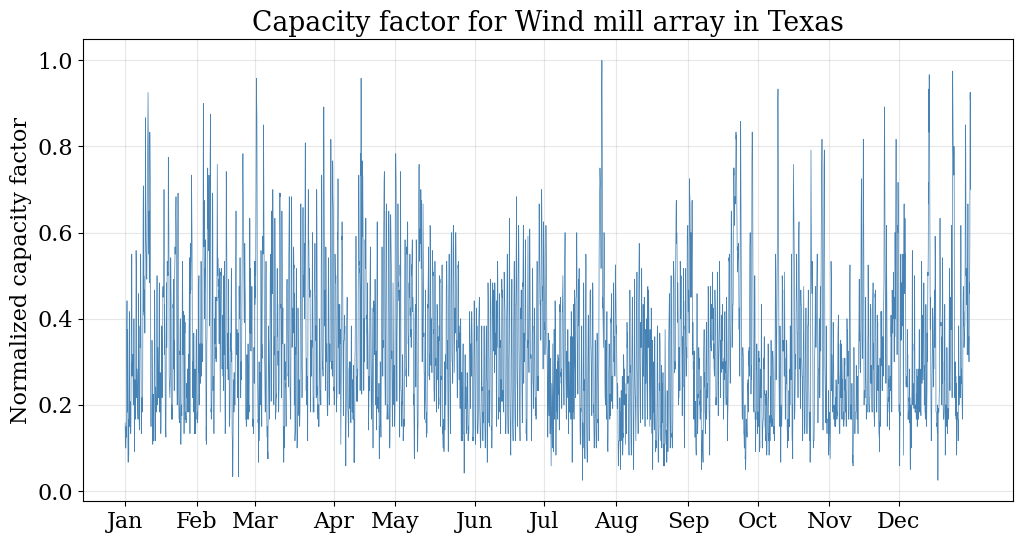

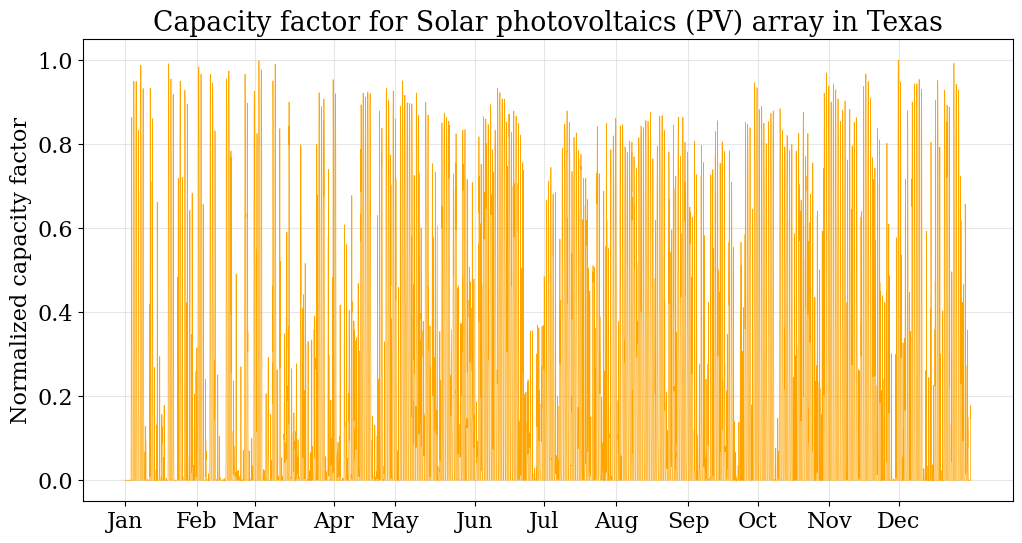

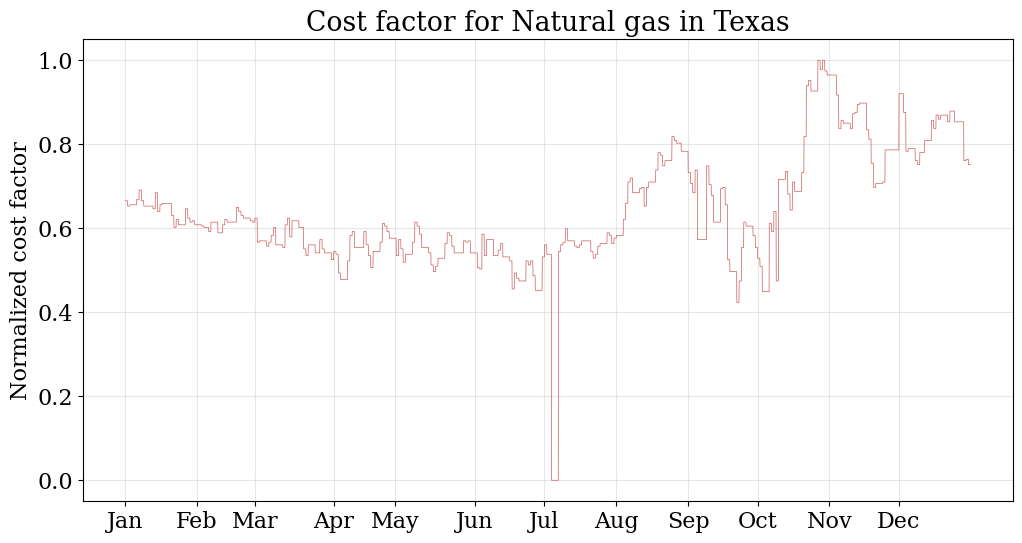

In [26]:
plot.capacity_factor(process= WF, location=TX1, color = 'steelblue')
plot.capacity_factor(process= PV, location=TX1, color = 'orange')
plot.cost_factor(resource= CH4, location=TX1, color = 'indianred')


**Scenario 2**

95% CCUS - Base Case

In [14]:
processes2 = {LiI_c, LiI_d, CAES_c, CAES_d, PSH_c, PSH_d, #power storage\ 
    WF, PV, #ASMR,  #power production\
        AKE, SMRH, ASU, HB, #DEC production\
            EOR, AQoff_SMR } # CCU
TX2 = Location(name='TX2', processes= processes2, cost_factor = {CH4: ng_price}, \
        capacity_factor = {PV: pandas.DataFrame(weather['dni']), WF: pandas.DataFrame(weather['wind_speed'])},\
            scales=scales, demand_level=1, capacity_level= 2, cost_level= 2, label = 'Texas')
scenario2 = Scenario(name= 'HyvAmm2', network= TX2, scales= scales,expenditure_scale_level= 2, \
    scheduling_scale_level = 2, demand_scale_level = 1, network_scale_level = 0, label= 'Hyv Ammonia')

scenario_reduced2, rep_days_stretch,  info =  reduce_scenario(
    scenario=scenario2, location= TX2, periods=40, scale_level=1, method=Clustermethod.agg_hierarchial,\
        include = ['capacity', 'cost'])

milp2 = formulate(scenario= scenario_reduced2, demand= demand,\
        constraints={Constraints.cost, Constraints.inventory, Constraints.production, Constraints.resource_balance}, \
                objective= Objective.cost)

results2 = solve(scenario = scenario_reduced2, instance= milp2, solver= 'gurobi', \
    name=f"ammonia_cs", print_solversteps = True)

set()
process capex constraint


<IPython.core.display.Math object>

process fopex constraint


<IPython.core.display.Math object>

process vopex constraint


...

demand constraint


<IPython.core.display.Math object>

cost objective


<IPython.core.display.Math object>

Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 45276 rows, 31889 columns and 133213 nonzeros
Model fingerprint: 0xa64c141b
Variable types: 31856 continuous, 33 integer (33 binary)
Coefficient statistics:
  Matrix range     [5e-08, 1e+10]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e+04, 1e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 26527 rows and 17939 columns
Presolve time: 0.24s
Presolved: 18749 rows, 13950 columns, 58574 nonzeros
Variable types: 13939 continuous, 11 integer (11 binary)
Found heuristic solution: objective 7.948857e+08
Found heuristic solution: objective 4.641047e+08

Root relaxation: objective 1.478061e+08, 6366 iterations, 0.34 seconds (0.40 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl U

In [15]:
milp2.cost_objective()/(demand*365)

4.676774190507205

In [16]:
(milp2.Capex_process[('TX2', 'WF', 0)].value)/(demand*365)

3.149364134632038

In [17]:
(milp2.cost_objective() - milp2.Capex_process[('TX2', 'WF', 0)].value)/(demand*365)

1.5274100558751667

In [18]:
processes3 = {LiI_c, LiI_d, CAES_c, CAES_d, PSH_c, PSH_d, #power storage\ 
    WF, PV, #ASMR,  #power production\
        AKE, ASU, HB, #DEC production\
            EOR, AQoff_SMR } # CCU
TX3 = Location(name='TX3', processes= processes3, cost_factor = {CH4: ng_price}, \
        capacity_factor = {PV: pandas.DataFrame(weather['dni']), WF: pandas.DataFrame(weather['wind_speed'])},\
            scales=scales, demand_level=1, capacity_level= 2, cost_level= 2, label = 'Texas')
scenario3 = Scenario(name= 'HyvAmm2', network= TX3, scales= scales,expenditure_scale_level= 2, \
    scheduling_scale_level = 2, demand_scale_level = 1, network_scale_level = 0, label= 'Hyv Ammonia')

scenario_reduced3, rep_days_stretch,  info =  reduce_scenario(
    scenario=scenario3, location= TX3, periods=40, scale_level=1, method=Clustermethod.agg_hierarchial,\
        include = ['capacity', 'cost'])

milp3 = formulate(scenario= scenario_reduced3, demand= demand,\
        constraints={Constraints.cost, Constraints.inventory, Constraints.production, Constraints.resource_balance}, \
                objective= Objective.cost)

results3 = solve(scenario = scenario_reduced3, instance= milp3, solver= 'gurobi', \
    name=f"ammonia_cs", print_solversteps = True)

set()
process capex constraint


<IPython.core.display.Math object>

process fopex constraint


<IPython.core.display.Math object>

process vopex constraint


...

demand constraint


<IPython.core.display.Math object>

cost objective


<IPython.core.display.Math object>

Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 41424 rows, 28993 columns and 118813 nonzeros
Model fingerprint: 0x50091f25
Variable types: 28962 continuous, 31 integer (31 binary)
Coefficient statistics:
  Matrix range     [5e-08, 1e+10]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e+04, 1e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 26553 rows and 17958 columns
Presolve time: 0.15s
Presolved: 14871 rows, 11035 columns, 42179 nonzeros
Variable types: 11028 continuous, 7 integer (7 binary)

Root relaxation: objective 3.394820e+08, 3089 iterations, 0.24 seconds (0.31 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0 

In [19]:
milp3.cost_objective()/(demand*365)

10.741645102923655

In [20]:
(milp3.Capex_process[('TX3', 'WF', 0)].value)/(demand*365)

8.68165571114455

In [21]:
(milp3.cost_objective() - milp3.Capex_process[('TX3', 'WF', 0)].value)/(demand*365)

2.0599893917791063

In [22]:
milp1.S_network.pprint()
milp2.S_network.pprint()
milp3.S_network.pprint()


S_network : Total resource discharge from network
    Size=3, Index=S_network_index
    Key             : Lower : Value              : Upper : Fixed : Stale : Domain
    ('CO2_Vent', 0) :     0 : 1282344721.6499958 :  None : False :  True : NonNegativeReals
         ('NH3', 0) :     0 :  758502808.9887557 :  None : False :  True : NonNegativeReals
          ('O2', 0) :     0 : 194629770.77892655 :  None : False :  True : NonNegativeReals
S_network : Total resource discharge from network
    Size=3, Index=S_network_index
    Key             : Lower : Value              : Upper : Fixed : Stale : Domain
    ('CO2_Vent', 0) :     0 : 139063904.99999997 :  None : False :  True : NonNegativeReals
         ('NH3', 0) :     0 :  758502808.9887557 :  None : False :  True : NonNegativeReals
          ('O2', 0) :     0 : 194629770.77892655 :  None : False :  True : NonNegativeReals
S_network : Total resource discharge from network
    Size=3, Index=S_network_index
    Key             : Lower : Va

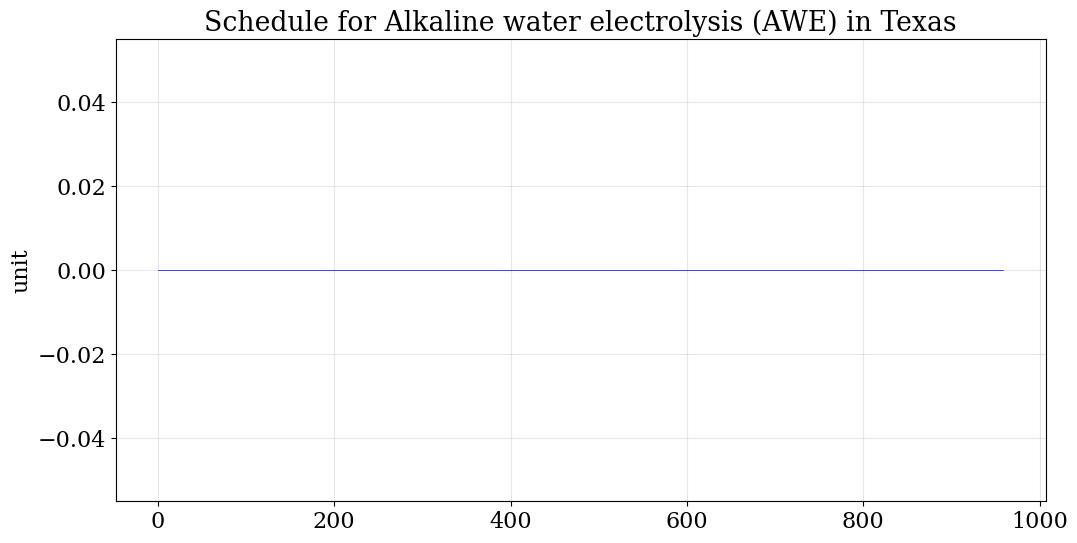

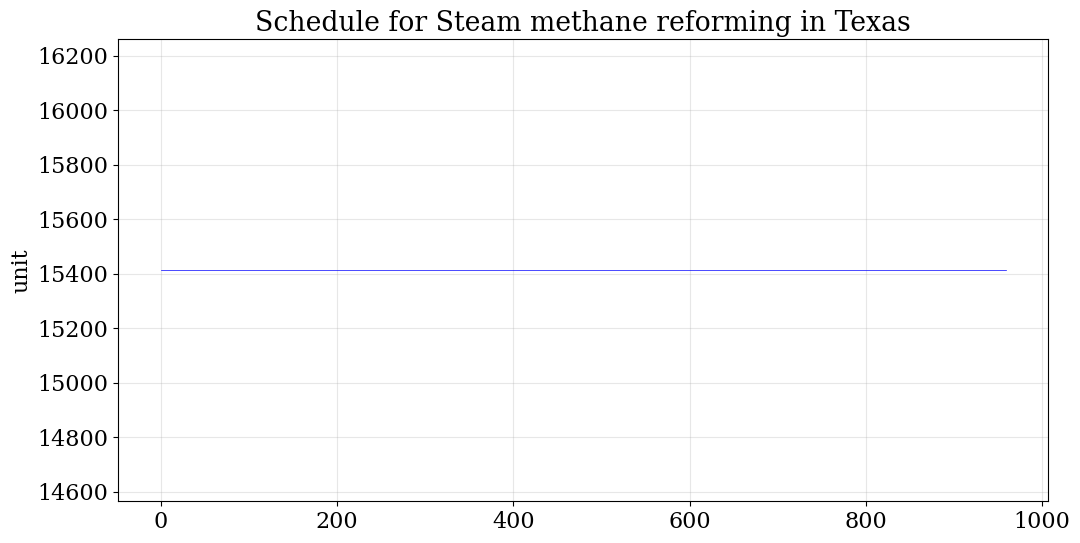

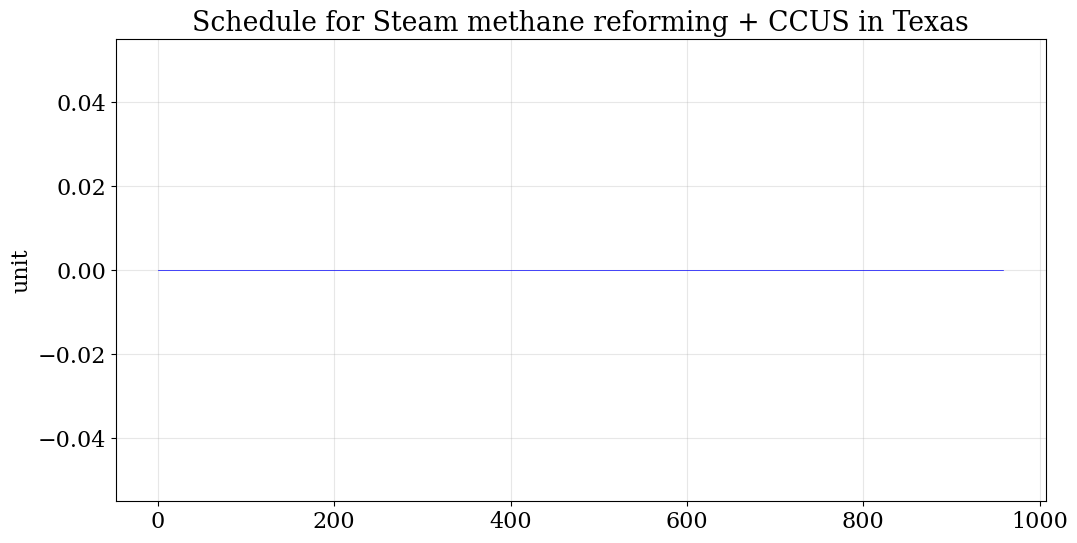

In [23]:
plot.schedule(results= results1, y_axis= 'P', component= 'AKE', location= 'TX1')
plot.schedule(results= results1, y_axis= 'P', component= 'SMR', location= 'TX1')
plot.schedule(results= results1, y_axis= 'P', component= 'SMRH', location= 'TX1')

In [24]:
plot.schedule(results= results, y_axis= 'C', component= 'H2O', location= 'TX')


NameError: name 'results' is not defined

In [ ]:
milp.X_P.pprint()

In [ ]:
milp.Capex_process.pprint()

In [ ]:
(milp.cost_objective() - milp.Capex_process[('TX', 'WF', 0)].value)/(demand*365)

In [ ]:
milp.Vopex_process.pprint()

In [ ]:
milp.B_network.pprint()

In [ ]:
# milp.resource_purchase_constraint.pprint()


In [ ]:
# milp.nameplate_production_constraint.pprint()

In [ ]:
# milp.storage_facility_constraint.pprint()

In [ ]:
# milp.location_production_constraint.pprint()

In [ ]:
# milp.inventory_balance_constraint.pprint()


In [ ]:
# milp.demand_constraint.pprint()

In [ ]:
# milp.resources_demand.pprint()


In [ ]:
# milp.resources_sell.pprint()

In [ ]:
# milp.resources_purch.pprint()

In [ ]:
# milp.resources_demand.pprint()

In [ ]:
factory.__dict__.keys()

In [ ]:
scenario.conversion.keys()

In [ ]:
for i in list(scenario.resource_set):
    print(i.name)

In [ ]:
milp.inventory_balance_constraint[factory.name,'StdBld1_stored',0, 1].pprint()

In [ ]:
milp.storage_facility_constraint.pprint()

In [ ]:
# milp.storage_facility_constraint.pprint()

In [ ]:
milp.demand_constraint.pprint()